In [2]:
from src import ttl
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
base_data_path = '/Volumes/AhmedLab/princess/data/testers/timesynch_tests'

# from 2p
ttl_path = f'{base_data_path}/TSeries_20251218-513_Cycle00001_VoltageRecording_001.csv'
ttl_csv = ttl.read_csv(ttl_path)

# from Bonsai


In [12]:
print(ttl_csv)

         Time(ms)     Scope  Side Camera      Opto
0            0.00  0.000610     1.381836  0.000305
1            0.01  0.000000     3.105774  0.000305
2            0.02  0.000000     3.242798  0.000610
3            0.03 -0.000305     3.280640  0.000000
4            0.04  0.000000     3.288879  0.000305
...           ...       ...          ...       ...
6047296  60472.96  0.000000     0.130615  0.000000
6047297  60472.97  0.000305     0.137634  0.000305
6047298  60472.98  0.000305     0.132446  0.000305
6047299  60472.99  0.000305     0.122375  0.000305
6047300  60473.00  0.000610     0.122375  0.000305

[6047301 rows x 4 columns]


In [5]:
np.floor(ttl_csv.mean(axis=0))

Time(ms)       30236.0
Scope              0.0
Side Camera        3.0
Opto               0.0
dtype: float64

In [6]:
def extract_relative_timestamps(data, threshold = 3):
    on_signals = data[data['Opto'] > threshold]
    first_signal = on_signals['Time(ms)'].iloc[0]

    timestamps = on_signals[on_signals['Time(ms)'].diff() > 2 * ttl.get_TTL_frame_period(data)]['Time(ms)']
    timestamps = np.concatenate([[first_signal], timestamps.to_numpy()])

    return timestamps

In [7]:
scope_timestamps_ttl = ttl.extract_2p_relative_timestamps(ttl_csv)
camera_timestamps_ttl = ttl.extract_camera_relative_timestamps(ttl_csv)
opto_timestamps_ttl = extract_relative_timestamps(ttl_csv) # only shows on times

In [8]:
print(max(ttl_csv['Time(ms)']))

60473.0


In [13]:
print(opto_timestamps_ttl)
print(scope_timestamps_ttl)

[  500.01 10500.27 20500.53 30500.79 40501.05 50501.31]
[9.000000e-02 6.651000e+01 1.328100e+02 1.991000e+02 2.654000e+02
 3.317000e+02 3.980000e+02 4.643000e+02 5.306000e+02 5.970300e+02
 6.633300e+02 7.296300e+02 7.959200e+02 8.622200e+02 9.285200e+02
 9.948200e+02 1.061120e+03 1.127420e+03 1.193720e+03 1.260020e+03
 1.326320e+03 1.392620e+03 1.458920e+03 1.525220e+03 1.591520e+03
 1.657820e+03 1.724120e+03 1.790420e+03 1.856720e+03 1.923140e+03
 1.989440e+03 2.055740e+03 2.122040e+03 2.188340e+03 2.254640e+03
 2.320940e+03 2.387240e+03 2.453540e+03 2.519840e+03 2.586140e+03
 2.652440e+03 2.718740e+03 2.785040e+03 2.851340e+03 2.917640e+03
 2.983940e+03 3.050240e+03 3.116540e+03 3.182840e+03 3.249140e+03
 3.315440e+03 3.381870e+03 3.448170e+03 3.514470e+03 3.580770e+03
 3.647070e+03 3.713370e+03 3.779670e+03 3.845970e+03 3.912270e+03
 3.978570e+03 4.044870e+03 4.111170e+03 4.177470e+03 4.243770e+03
 4.310070e+03 4.376370e+03 4.442670e+03 4.508970e+03 4.575270e+03
 4.641570e+03 4.7078

(0.0, 20600.53)

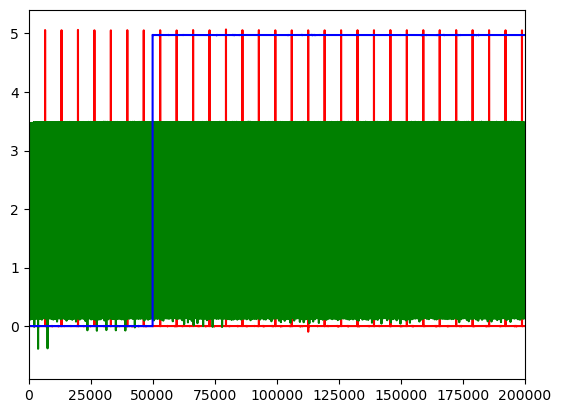

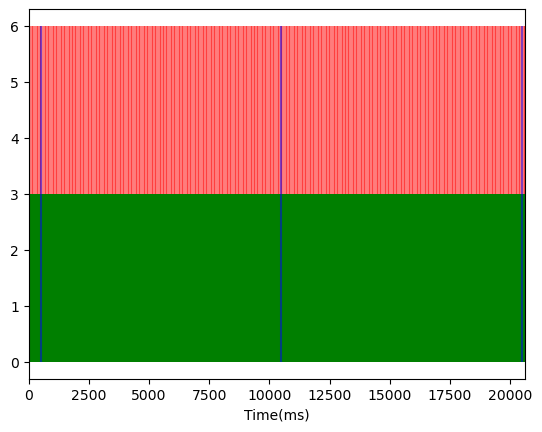

In [18]:
# plot all frame timestamps

plt.plot(ttl_csv['Scope'], color='r')
plt.plot(ttl_csv['Side Camera'], color='g')
plt.plot(ttl_csv['Opto'], color='b')
plt.xlim(0, 200000)

plt.figure()
plt.vlines(scope_timestamps_ttl,0,6, colors='r', alpha=0.5)
plt.vlines(camera_timestamps_ttl,0,3, colors='g', alpha=0.5)
plt.vlines(opto_timestamps_ttl,0,6, colors='b', alpha=0.5)
plt.xlabel('Time(ms)')
plt.xlim(0,opto_timestamps_ttl[2]+100)

In [110]:
bonsai_path = f'{base_data_path}/202624_synchtest_time2026-02-04T16_00_21.csv'
bonsai_csv = pd.read_csv(bonsai_path, header=None)
print(bonsai_csv, bonsai_csv.dtypes)

                                0
0     2026-02-04T16:00:21.6495872
1     2026-02-04T16:00:21.6562944
2     2026-02-04T16:00:21.6637440
3     2026-02-04T16:00:21.6724352
4     2026-02-04T16:00:21.6791424
...                           ...
7767  2026-02-04T16:01:21.0733952
7768  2026-02-04T16:01:21.0810368
7769  2026-02-04T16:01:21.0889088
7770  2026-02-04T16:01:21.0964608
7771  2026-02-04T16:01:21.1040256

[7772 rows x 1 columns] 0    object
dtype: object


In [100]:
from datetime import datetime

In [102]:
bonsai_ts_arr = bonsai_csv[0].to_numpy()

In [104]:
test = bonsai_ts_arr[0]
test = test[:-1]
print(test)
test2 = bonsai_ts_arr[1][:-1]

dt_test = datetime.strptime(test, '%Y-%m-%dT%H:%M:%S.%f')
dt_test2 = datetime.strptime(test2, '%Y-%m-%dT%H:%M:%S.%f')
print(dt_test, dt_test2)

diff = dt_test2 - dt_test # needs a date to subtract, won't work with just time

2026-02-04T16:00:21.649587
2026-02-04 16:00:21.649587 2026-02-04 16:00:21.656294


In [105]:
# loop over all times
bonsai_timestamps = []
for time in bonsai_ts_arr:
    shortened_time = time[:-1] # datetime can only handle 6 digits in the milliseconds

    # convert string to datetime format
    dt_object = datetime.strptime(shortened_time, '%Y-%m-%dT%H:%M:%S.%f')
    bonsai_timestamps.append(dt_object)

start_time = bonsai_timestamps[0]

# to calculate time relative to first frame
relative_bonsai_timestamps = []
for i, ts in enumerate(bonsai_timestamps):
    # if i == 0:
    #     # print(bonsai_timestamps[i])
    # #     relative_bonsai_timestamps.append(str(bonsai_timestamps[i]-start_time))
    #     relative_bonsai_timestamps.append(bonsai_timestamps[i]-start_time)
    relative_bonsai_timestamps.append((bonsai_timestamps[i]-start_time).total_seconds())
    # relative_bonsai_timestamps.append(str(bonsai_timestamps[i]-bonsai_timestamps[i-1]))
relative_bonsai_timestamps_ms = [x*1000 for x in relative_bonsai_timestamps]

[0.0, 0.006707, 0.014157, 0.022848, 0.029555, 0.037094, 0.044838, 0.052352, 0.06016, 0.06784, 0.075341, 0.083853, 0.090598, 0.098278, 0.105881, 0.113677, 0.121318, 0.128985, 0.136473, 0.144269, 0.151949, 0.159475, 0.167257, 0.174758, 0.182553, 0.190093, 0.197683, 0.205337, 0.213107, 0.220902, 0.228659, 0.235968, 0.244301, 0.251328, 0.258893, 0.26656, 0.274265, 0.281881, 0.289523, 0.297357, 0.304819, 0.312448, 0.320128, 0.327731, 0.335629, 0.34304, 0.35072, 0.358566, 0.366169, 0.373645, 0.381299, 0.389081, 0.39703, 0.404275, 0.411904, 0.419737, 0.4272, 0.434931, 0.442662, 0.450304, 0.457971, 0.465459, 0.473126, 0.480973, 0.488448, 0.496307, 0.503705, 0.511373, 0.519027, 0.526758, 0.534387, 0.542003, 0.549632, 0.557414, 0.565005, 0.572595, 0.580275, 0.588083, 0.595533, 0.603328, 0.610893, 0.618598, 0.626304, 0.633843, 0.641613, 0.649254, 0.656742, 0.664371, 0.672525, 0.67968, 0.687347, 0.695091, 0.70263, 0.710272, 0.718016, 0.725593, 0.733273, 0.740889, 0.748569, 0.756403, 0.763878, 0.77

(59000.0, 60000.0)

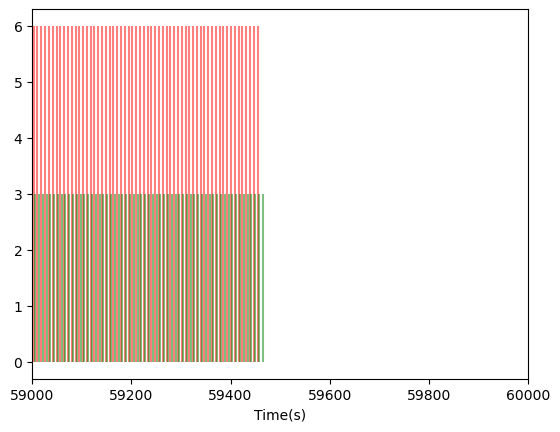

In [113]:
plt.vlines(relative_bonsai_timestamps_ms,0,6, colors='r', alpha=0.5)
plt.vlines(camera_timestamps_ttl,0,3, colors='g', alpha=0.5)
plt.xlabel('Time(s)')
plt.xlim(59000,60000)

In [108]:
print(len(relative_bonsai_timestamps), len(camera_timestamps_ttl))
print(relative_bonsai_timestamps_ms[0:10], camera_timestamps_ttl[0:10])
print(relative_bonsai_timestamps_ms[-10:], camera_timestamps_ttl[-10:])

7772 7774
[0.0, 6.707, 14.157, 22.848, 29.555, 37.094, 44.838, 52.352000000000004, 60.16, 67.84] [1.000e-02 7.660e+00 1.531e+01 2.297e+01 3.061e+01 3.827e+01 4.591e+01
 5.357e+01 6.122e+01 6.886e+01]
[59385.613, 59393.267, 59400.832, 59408.512, 59416.153, 59423.808000000005, 59431.449, 59439.320999999996, 59446.873, 59454.438] [59396.09 59403.75 59411.39 59419.05 59426.69 59434.35 59442.   59449.64
 59457.3  59464.94]


In [ ]:
opto_frames = []